<a href="https://colab.research.google.com/github/Roman-bib/Dyplom/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22proactive_scaler_pipeline_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Система прогнозирования пиковых нагрузок — полный пайплайн

**ВКР: «Разработка системы проактивного масштабирования веб-приложений»**

| Секция | Глава ВКР | Что делает |
|--------|-----------|------------|
| §3.4 EDA | Глава 3 | Загрузка данных, разведочный анализ |
| §4.1 Модели | Глава 4 | XGBoost (Random Search) + LSTM (Random Search) + NeuralProphet (Grid Search) |
| §4.2 Пики | Глава 4 | Детекция пиковых нагрузок |
| §4.3 Walk-Forward | Глава 4 | Адаптивное переобучение с ADWIN-детектором дрейфа |

> **Запускай ячейки строго сверху вниз** (Runtime → Run all, или по одной)

## 0. Установка и клонирование

In [1]:
import os, sys

REPO_DIR = '/content/Dyplom'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Roman-bib/Dyplom.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

Already up to date.


In [2]:
# обновление библиотек
!pip install -q xgboost neuralprophet tensorflow scikit-learn pandas "numpy<2.0" \
               matplotlib seaborn river joblib

## 1. Конфигурация — измени CSV_PATH под свои данные

In [3]:
import os, sys
REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

# ================================================================
# НАСТРОЙКА — меняй только здесь
# ================================================================

CSV_PATH  = "/content/drive/MyDrive/Colab Notebooks/SDV_hourly.csv"
SAVE_DIR  = "/content/results"

# True = пропустить NeuralProphet (~15 мин экономии)
FAST_MODE = False

# Walk-Forward
WF_N_FRESH    = 200   # принудительный retrain каждые N шагов
WF_CONFIRM_N  = 10    # подтверждение ADWIN (шагов подряд)
WF_TEST_LIMIT = 500   # None = все точки теста

# ================================================================

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'CSV_PATH : {CSV_PATH}')
print(f'SAVE_DIR : {SAVE_DIR}')
print(f'FAST_MODE: {FAST_MODE}')

CSV_PATH : /content/drive/MyDrive/Colab Notebooks/SDV_hourly.csv
SAVE_DIR : /content/results
FAST_MODE: False


### Настройка визуализации

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 14,

    # Рамка
    'axes.edgecolor': '#000000',
    'axes.linewidth': 0.5,

    # --- ВКЛЮЧЕНИЕ СЕТКИ (ДОБАВЛЕНО) ---
    'axes.grid': True,              # Эта строка включает сетку
    'grid.color': '#eaeaf2',        # Цвет сетки
    'grid.linestyle': '-',          # Сплошная линия
    'grid.alpha': 1,              # Прозрачность (0.0 - 1.0)
    # ----------------------------------

    # Засечки
    'xtick.major.size': 3,
    'xtick.major.width': 0.5,
    'ytick.major.size': 3,
    'ytick.major.width': 0.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    'xtick.color': '#000000',
    'ytick.color': '#000000',
})


## 2. Монтирование Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Загрузка данных

In [6]:
import os, sys
REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from google.colab import files
warnings.filterwarnings('ignore')

import config as _cfg
from data_collection.csv_loader import load_csv

df = load_csv(CSV_PATH, extra_cols=getattr(_cfg, "EXOG_COLS", []))

# Имитация пропусков (сбои сбора метрик)
rng = np.random.default_rng(42)
mask = rng.random(len(df)) < 0.02
df.loc[mask, "y"] = np.nan
df.loc[150:152, "y"] = np.nan
df.loc[800:803, "y"] = np.nan

  timestamp → 'ds',  value → 'rps'


## §3.4 — EDA

In [ ]:
# Таблица исходная
import pandas as pd
df_raw = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SDV_hourly.csv", nrows=3)
print(df_raw.columns.tolist())
print(df_raw.head(3))

['ds', 'rps', 'is_weekend', 'hour', 'day_of_week', 'is_holiday', 'is_campaign', 'is_promo']
                    ds          rps  is_weekend  hour  day_of_week  \
0  2023-01-01 00:00:00  4202.060764           1     0            6   
1  2023-01-01 01:00:00  4120.802737           1     1            6   
2  2023-01-01 02:00:00  4112.734845           1     2            6   

   is_holiday  is_campaign  is_promo  
0           1            0         0  
1           1            0         0  
2           1            0         0  


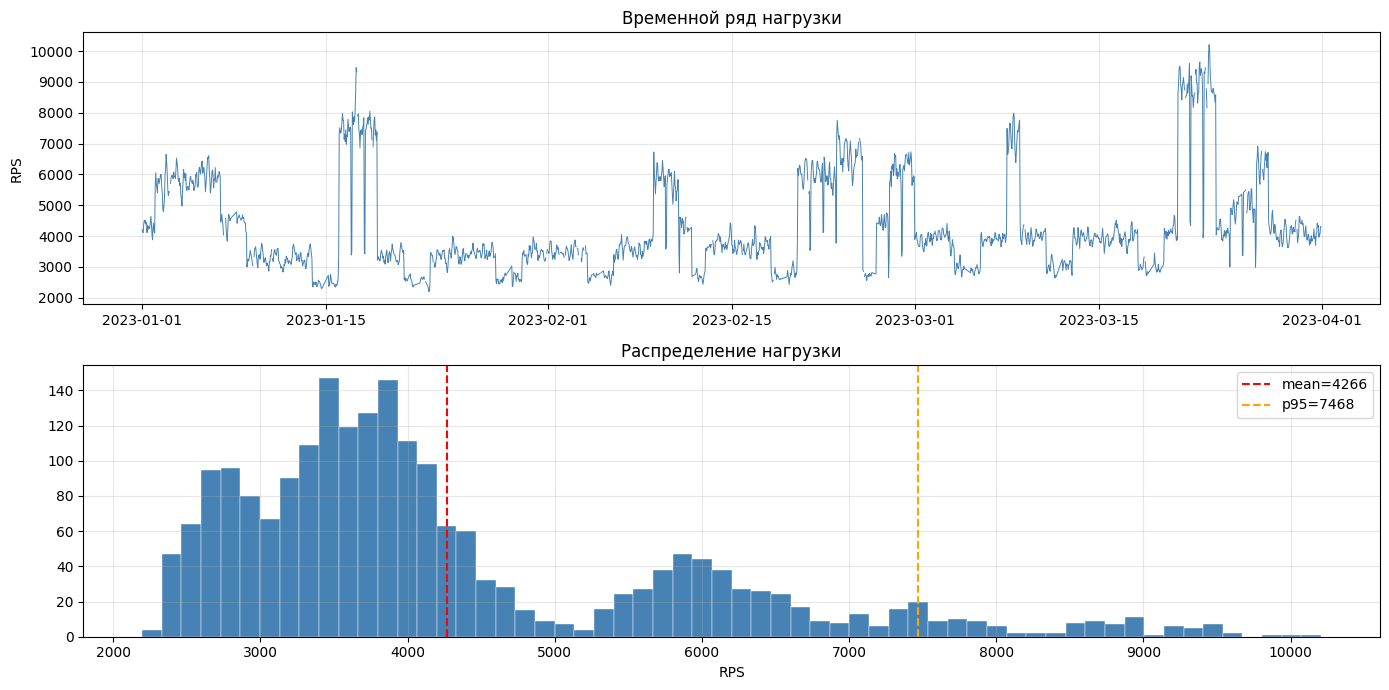

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

ax = axes[0]
ax.plot(df['ds'], df['y'], linewidth=0.7, color='steelblue')
ax.set_title('Временной ряд нагрузки')
ax.set_ylabel('RPS'); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(df['y'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(df['y'].mean(),          color='red',    linestyle='--', label=f'mean={df["y"].mean():.0f}')
ax.axvline(df['y'].quantile(0.95),  color='orange', linestyle='--', label=f'p95={df["y"].quantile(0.95):.0f}')
ax.set_title('Распределение нагрузки'); ax.set_xlabel('RPS')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eda_overview.png', dpi=150)
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

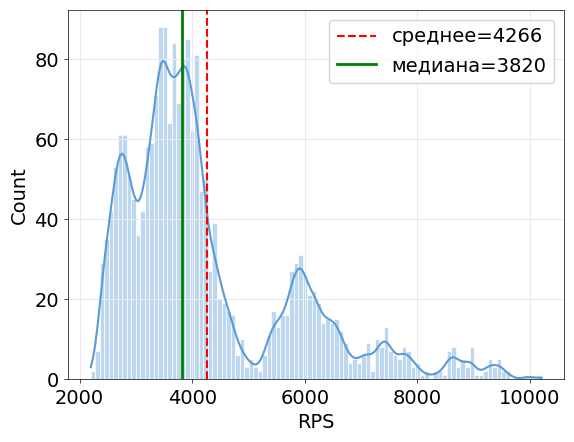

In [ ]:
import seaborn as sns
sns.histplot(
    data=df,
    x=df['y'],
    bins=100,
    kde=True,
    fill=True,
    color='#5b9bd5',
    alpha=0.4,
    edgecolor='white',
    linewidth=0.5,
    kde_kws={"bw_adjust": 0.3},  # ← меньше = точнее следует столбцам
)
plt.axvline(df['y'].mean(),
            color='red',
            linestyle='--',
            label=f'среднее={df["y"].mean():.0f}')

# Добавляем МЕДИАНУ (добавленная строка)
plt.axvline(df['y'].median(),
            color='green',
            linestyle='-',
            linewidth=2,
            label=f'медиана={df["y"].median():.0f}')

# Важно: добавляем легенду, чтобы метки отобразились
plt.legend()
plt.xlabel('RPS')
plt.savefig('histogram.svg', format='svg', bbox_inches='tight')
files.download("histogram.svg")

In [ ]:
df['hour']      = pd.to_datetime(df['ds']).dt.hour
df['dayofweek'] = pd.to_datetime(df['ds']).dt.dayofweek
dow_names = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly = df.groupby('hour')['y'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].set_title('Средняя нагрузка по часам суток')
axes[0].set_xlabel('Час'); axes[0].set_ylabel('RPS'); axes[0].grid(alpha=0.3, axis='y')

daily = df.groupby('dayofweek')['y'].mean()
axes[1].bar([dow_names[i] for i in daily.index], daily.values, color='orange', edgecolor='white')
axes[1].set_title('Средняя нагрузка по дням недели')
axes[1].set_ylabel('RPS'); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eda_seasonality.png', dpi=150)
plt.show()

df.drop(columns=['hour', 'dayofweek'], inplace=True)

## Разбиение train / val / test

Train : 1440 (2023-01-01 00:00:00 → 2023-03-01 23:00:00)
Val   : 360 (2023-03-02 00:00:00 → 2023-03-16 23:00:00)
Test  : 360 (2023-03-17 00:00:00 → 2023-03-31 23:00:00)


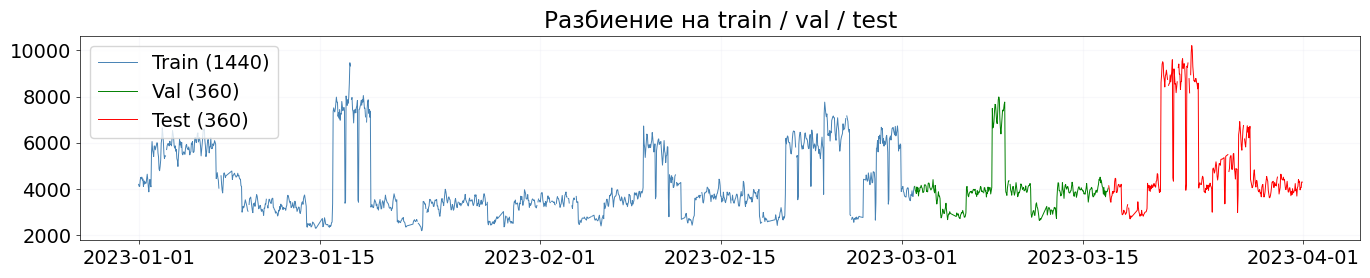

In [7]:
import os, sys
REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

import pandas as pd
import matplotlib.pyplot as plt

from preprocessing.feature_engineering import split_train_val_test

n = len(df)
TEST_H = min(480, n // 6)
VAL_H  = TEST_H

train, val, test = split_train_val_test(df, test_hours=TEST_H, val_hours=VAL_H)
print(f'Train : {len(train)} ({train["ds"].iloc[0]} → {train["ds"].iloc[-1]})')
print(f'Val   : {len(val)} ({val["ds"].iloc[0]} → {val["ds"].iloc[-1]})')
print(f'Test  : {len(test)} ({test["ds"].iloc[0]} → {test["ds"].iloc[-1]})')

train.to_csv(f'{SAVE_DIR}/train.csv', index=False)
val.to_csv(f'{SAVE_DIR}/val.csv', index=False)
test.to_csv(f'{SAVE_DIR}/test.csv', index=False)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(train['ds'], train['y'], color='steelblue', linewidth=0.7, label=f'Train ({len(train)})')
ax.plot(val['ds'],   val['y'],   color='green',     linewidth=0.7, label=f'Val ({len(val)})')
ax.plot(test['ds'],  test['y'],  color='red',        linewidth=0.7, label=f'Test ({len(test)})')
ax.set_title('Разбиение на train / val / test')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/data_split.png', dpi=150)
plt.show()

## §4.1 — Сравнение моделей (с подбором гиперпараметров)

- **XGBoost** — Random Search, 30 итераций, 7 параметров
- **LSTM** — Random Search, 10 итераций, 5 параметров, Huber loss
- **NeuralProphet** — Grid Search, 8 комбинаций (отключается `FAST_MODE=True`)

In [ ]:
import os, sys
import importlib
import pandas as pd
import numpy as np

REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

from models.comparison import ModelComparison
from preprocessing.feature_engineering import split_train_val_test, _infer_step_minutes, _hours_to_periods
from data_collection.csv_loader import load_csv
import config as _cfg

importlib.reload(_cfg)
df_full = load_csv(CSV_PATH, extra_cols=_cfg.EXOG_COLS)
print(f"Экзогенные признаки: {_cfg.EXOG_COLS}")

n = len(df_full)
TEST_H = min(480, n // 6)
VAL_H  = TEST_H
train, val, test = split_train_val_test(df_full, test_hours=TEST_H, val_hours=VAL_H)

step_min    = _infer_step_minutes(pd.to_datetime(train['ds']))
lstm_window = max(12, min(_hours_to_periods(24, step_min), 288))
print(f'Шаг данных: {step_min} мин  |  LSTM window_size: {lstm_window}')

comparator = ModelComparison(model_save_dir=SAVE_DIR)
results = comparator.run(
    train, val, test,
    include_prophet   = not FAST_MODE,
    include_lstm      = True,
    include_fbprophet = not FAST_MODE,
    lstm_window_size  = lstm_window,
    force_retrain     = True,
)

comparator.save_best()
best_name, best_model = comparator.best_model()
print(f'\nЛучшая модель: {best_name}')

  timestamp → 'ds',  value → 'rps'
Экзогенные признаки: ['is_holiday', 'is_campaign', 'is_promo']
Шаг данных: 60.0 мин  |  LSTM window_size: 24
СРАВНЕНИЕ МОДЕЛЕЙ ПРОГНОЗИРОВАНИЯ

[1] XGBoost (Random Search)...
  XGBoost Random Search: 30 итераций...
    [1/30] новый лучший RMSE=390.4810  params={'max_depth': 4, 'learning_rate': 0.07, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'reg_alpha': 0.3, 'reg_lambda': 0.5}
    [2/30] новый лучший RMSE=359.2525  params={'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.6, 'colsample_bytree': 0.8, 'min_child_weight': 7, 'reg_alpha': 0.1, 'reg_lambda': 2.0}


INFO - (NP.config.__post_init__) - Note: Trend changepoint regularization is experimental.
INFO:NP.config:Note: Trend changepoint regularization is experimental.
INFO - (NP.config.__post_init__) - Note: Fourier-based seasonality regularization is experimental.
INFO:NP.config:Note: Fourier-based seasonality regularization is experimental.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.931% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.931% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h
INFO:NP.df_utils:Defined frequency is equal to major frequency - h
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO:NP.config:Setting normalization to global as only one dataframe provided for training.
INFO - (N

  XGBoost Random Search завершён: RMSE=359.2525
  Лучшие параметры: {'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.6, 'colsample_bytree': 0.8, 'min_child_weight': 7, 'reg_alpha': 0.1, 'reg_lambda': 2.0}
  XGBoost              MAE=  502.07  RMSE=  827.50  MAPE=  8.06%
  [OK] Баланс (XGBoost): MAE_train=166.27, MAE_val=193.42 (разрыв 16.3%)

[2] Prophet (grid-search по гиперпараметрам, train-only)...
  NeuralProphet grid-search: 8 комбинаций (freq=h, yearly=False, holidays=False)


WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (45) is too small than the required number                     for the learning rate finder (229). The results might not be optimal.


Finding best initial lr:   0%|          | 0/229 [00:00<?, ?it/s]

...

  Best NeuralProphet: {'n_changepoints': 20, 'trend_reg': 1.0, 'seasonality_reg': 0.1, 'n_lags': 24, 'ar_reg': 0.1}  →  val MAE=218.88


Finding best initial lr:   0%|          | 0/231 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.944% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.944% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h
INFO:NP.df_utils:Defined frequency is equal to major frequency - h


  Prophet пропущен: Future values of all user specified regressors not provided

[3] LSTM (Random Search, window_size=24, Huber loss, fit-on-train scaler)...
  LSTM Random Search: 10 итераций × 30 эпох...
    [1/10] новый лучший MAE=305.7676  params={'units_l1': 32, 'units_l2': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32}
    [4/10] новый лучший MAE=289.7019  params={'units_l1': 128, 'units_l2': 32, 'dropout': 0.2, 'lr': 0.002, 'batch_size': 32}
  LSTM Random Search завершён, финальное обучение на 80 эпохах...


### Таблица метрик

In [9]:
# Таблица метрик
import pandas as pd

SHOW = ['MAE', 'RMSE', 'MAPE', 'train_time_s']
rows = []
for name, m in comparator.results_.items():
    if name == "FBProphet":
        continue
    row = {'Модель': name}
    row.update({c: m.get(c, float('nan')) for c in SHOW})
    if 'mae_train' in m:
        row['MAE_train']  = m['mae_train']
        row['MAE_val']    = m['mae_val']
        row['overfit']    = m['overfit_ratio']
    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index('Модель').round(3)
metrics_df.to_csv(f'{SAVE_DIR}/metrics_comparison.csv')
display(metrics_df)

,MAE,RMSE,MAPE,train_time_s,MAE_train,MAE_val,overfit
Модель,,,,,,,
XGBoost,502.072,827.498,8.064,7.79,166.266,193.425,0.163
Prophet,2084.502,2807.902,34.334,617.32,NaN,NaN,NaN
LSTM,660.985,980.462,11.754,404.23,0.201,0.239,0.192


### Визуализация метрик

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

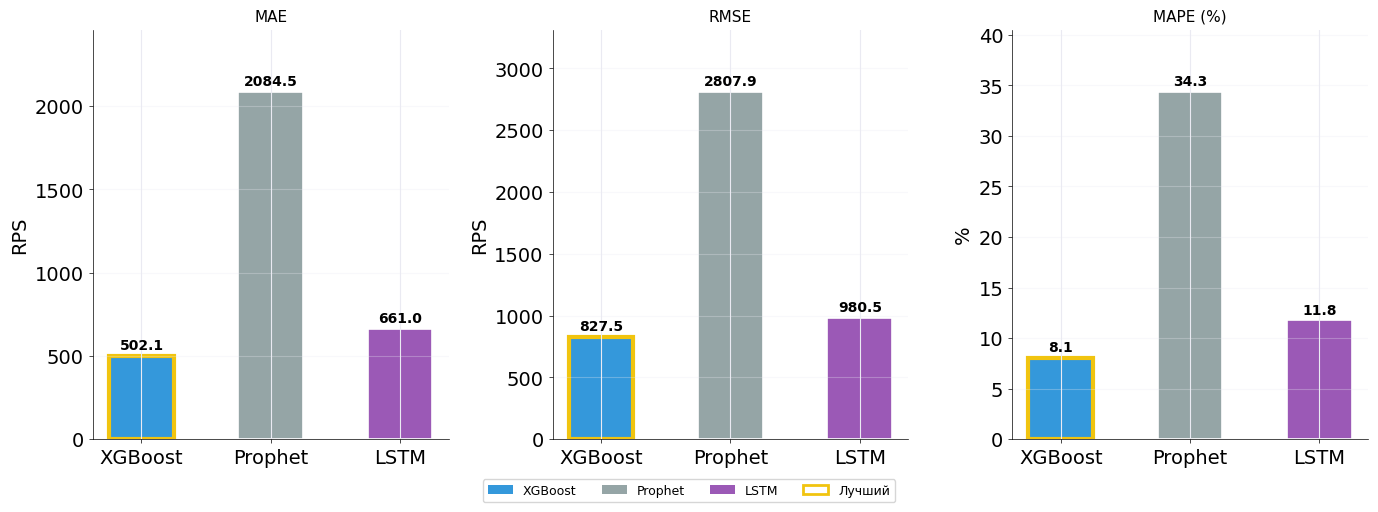

In [28]:
import matplotlib.pyplot as plt
import numpy as np

models = metrics_df.index.tolist()
metrics_to_plot = [
    ('MAE',  'MAE', 'RPS'),
    ('RMSE', 'RMSE',          'RPS'),
    ('MAPE', 'MAPE (%)',                   '%'),
]

colors = {'XGBoost': '#3498db', 'Prophet': '#95a5a6', 'LSTM': '#9b59b6'}
bar_colors = [colors.get(m, '#bdc3c7') for m in models]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
# fig.suptitle('Сравнение моделей прогнозирования', fontsize=14, fontweight='bold')

for ax, (col, title, ylabel) in zip(axes, metrics_to_plot):
    vals = metrics_df[col].values
    bars = ax.bar(models, vals, color=bar_colors, edgecolor='white',
                  linewidth=1.2, width=0.5)

    # подписи над столбцами
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.01,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # выделяем лучший (минимальный) золотой рамкой
    best_idx = int(np.nanargmin(vals))
    bars[best_idx].set_edgecolor('#f1c40f')
    bars[best_idx].set_linewidth(3)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.18)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m) for m, c in colors.items() if m in models]
legend_elements.append(Patch(facecolor='white', edgecolor='#f1c40f', linewidth=2, label='Лучший'))
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=9)

plt.tight_layout()
plt.savefig('srav.svg')
files.download("srav.svg")


In [11]:
import os, sys
REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

import matplotlib.pyplot as plt
from evaluation.metrics import plot_all_forecasts

plot_all_forecasts(train, val, test,
    predictions_dict=comparator.predictions_,
    save_path=f'{SAVE_DIR}/comparison_all_models.png', zoom=False)
plot_all_forecasts(train, val, test,
    predictions_dict=comparator.predictions_,
    save_path=f'{SAVE_DIR}/comparison_zoom.png', zoom=True)
plt.show()

Saved: /content/results/comparison_all_models.png
Saved: /content/results/comparison_zoom.png


### Важность признаков XGBoost

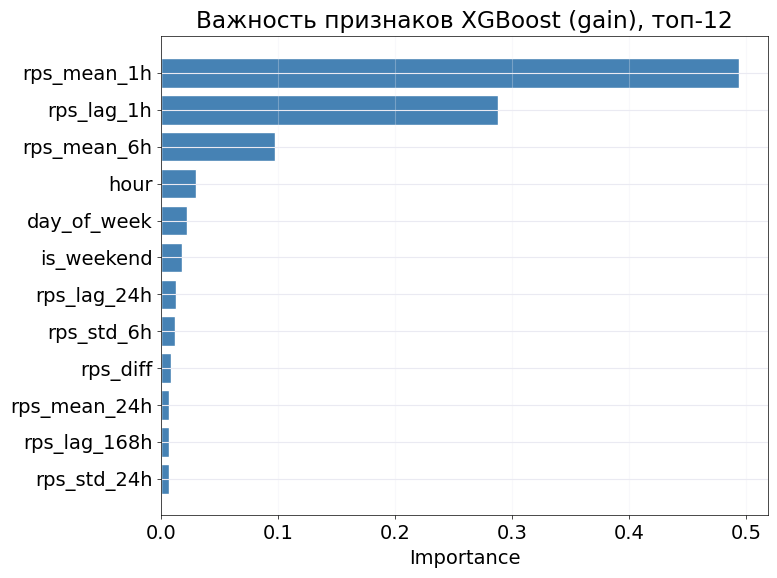

     feature  importance
 rps_mean_1h    0.493772
  rps_lag_1h    0.287538
 rps_mean_6h    0.097066
        hour    0.029777
 day_of_week    0.021796
  is_weekend    0.017837
 rps_lag_24h    0.012691
  rps_std_6h    0.011476
    rps_diff    0.008575
rps_mean_24h    0.006774
rps_lag_168h    0.006438
 rps_std_24h    0.006261
  rps_std_1h    0.000000


In [12]:
import os, sys
REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

import joblib, numpy as np
import matplotlib.pyplot as plt
from models.xgboost_model import feature_importance
from preprocessing.feature_engineering import FeatureBuilder

xgb_model = comparator.models_.get('XGBoost') or joblib.load(f'{SAVE_DIR}/xgboost.pkl')
builder   = FeatureBuilder()
X_tr_fi, _ = builder.get_X_y(train)

imp_df = feature_importance(xgb_model, feature_names=list(X_tr_fi.columns))
imp_df.to_csv(f'{SAVE_DIR}/feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 6))
top12 = imp_df.head(12).iloc[::-1]
ax.barh(top12['feature'], top12['importance'], color='steelblue', edgecolor='white')
ax.set_title('Важность признаков XGBoost (gain), топ-12')
ax.set_xlabel('Importance'); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/feature_importance.png', dpi=150)
plt.show()
print(imp_df.to_string(index=False))

### Доверительный интервал (квантильная регрессия 10–90%)

In [13]:
import os, sys
REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

import numpy as np
import matplotlib.pyplot as plt
from models.xgboost_model import get_confidence_interval
from evaluation.metrics import plot_forecast
from preprocessing.feature_engineering import FeatureBuilder

builder_ci = FeatureBuilder()
(X_tr, y_tr), (X_vl, y_vl), (X_te, y_te) = builder_ci.transform_splits(train, val, test)

print('Обучение квантильных моделей (q=0.10 и q=0.90)...')
lower, upper = get_confidence_interval(X_tr, y_tr, X_vl, y_vl, X_te, save_dir=SAVE_DIR)

xgb_preds = comparator.predictions_.get('XGBoost')
plot_forecast(train, val, test, xgb_preds, 'XGBoost',
              lower=lower, upper=upper,
              save_path=f'{SAVE_DIR}/forecast_xgb_ci.png', zoom=False)
plot_forecast(train, val, test, xgb_preds, 'XGBoost',
              lower=lower, upper=upper,
              save_path=f'{SAVE_DIR}/forecast_xgb_ci_zoom.png', zoom=True)
plt.show()

# Экспорт предсказаний с CI
pred_df = test[['ds','y']].iloc[:len(xgb_preds)].copy().reset_index(drop=True)
for name, p in comparator.predictions_.items():
    pred_df[name] = np.array(p[:len(pred_df)])
pred_df['XGBoost_lower'] = lower[:len(pred_df)]
pred_df['XGBoost_upper'] = upper[:len(pred_df)]
pred_df.to_csv(f'{SAVE_DIR}/predictions.csv', index=False)
print(f'Сохранено: {SAVE_DIR}/predictions.csv')

Обучение квантильных моделей (q=0.10 и q=0.90)...
Saved: /content/results/forecast_xgb_ci.png
Saved: /content/results/forecast_xgb_ci_zoom.png
Сохранено: /content/results/predictions.csv


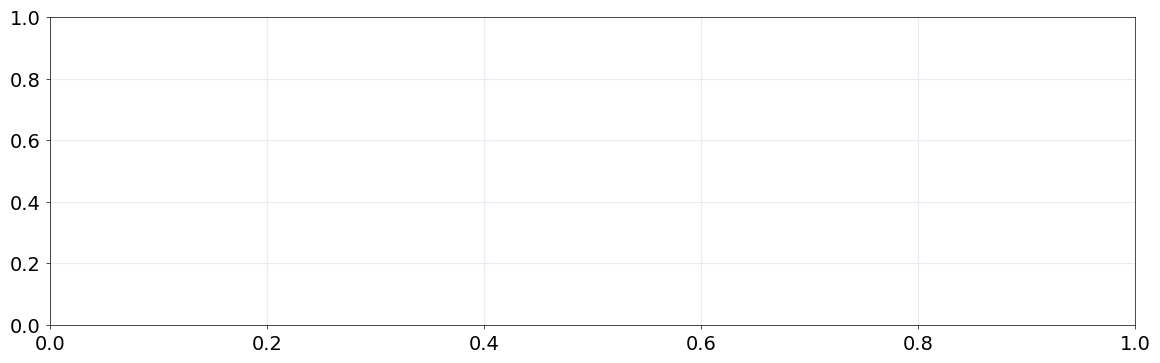

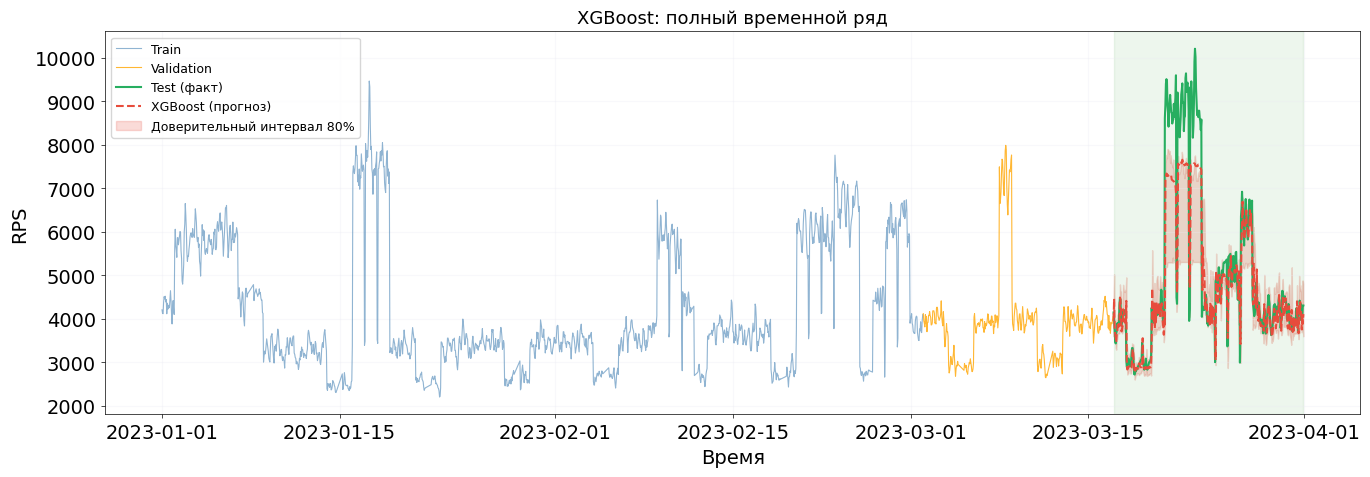

Полный горизонт


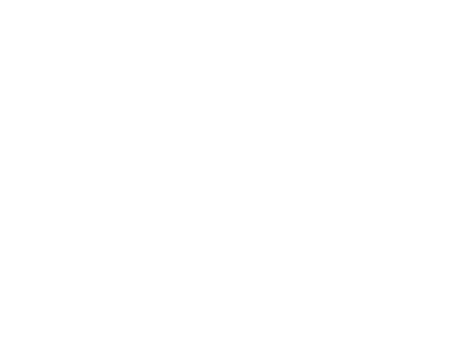

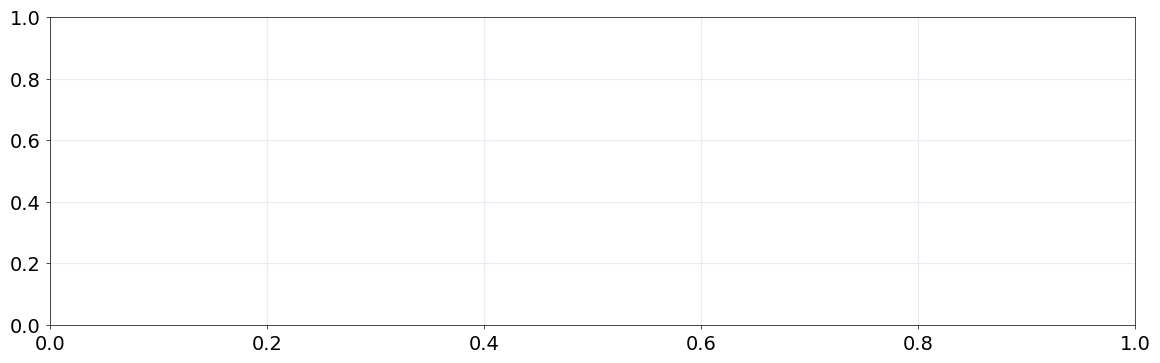

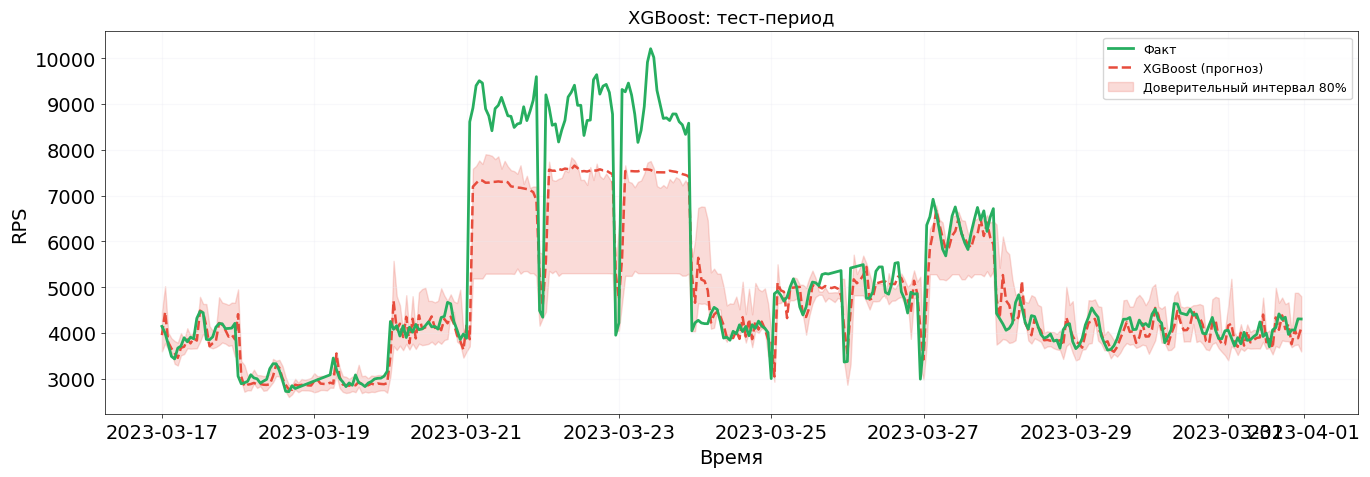

Zoom — тестовый период


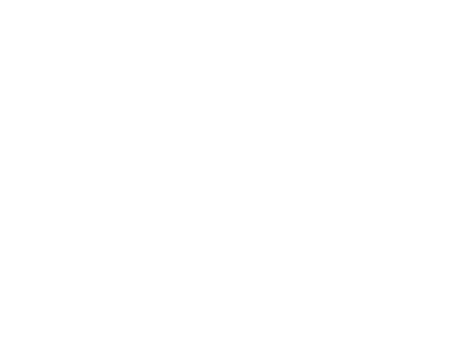

In [30]:
from io import StringIO
from IPython.display import SVG, display as ipy_display
import matplotlib.pyplot as plt

for title, zoom in [('Полный горизонт', False), ('Zoom — тестовый период', True)]:
    fig, ax = plt.subplots(figsize=(14, 4))
    plot_forecast(train, val, test, xgb_preds, 'XGBoost',
                  lower=lower, upper=upper,
                  save_path=None, zoom=zoom)
    buf = StringIO()
    plt.savefig(buf, format='svg', bbox_inches='tight')
    plt.savefig(f'{SAVE_DIR}/forecast_{"zoom" if zoom else "full"}.svg',
                format='svg', bbox_inches='tight')
    plt.close()
    print(title)
    ipy_display(SVG(buf.getvalue()))

## §4.2 — Детекция пиковых нагрузок

In [25]:
import os, sys
REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

import pandas as pd
import numpy as np
from evaluation.peak_detection import PeakDetector

test_demo = test.iloc[:48].copy()

rps_max = float(train['y'].max())
detector = PeakDetector(
    method='rolling_std', k=2.0,
    target_rps_per_replica=rps_max / 10,
    min_replicas=1, max_replicas=10,
)
detector.fit(train['y'])

# Берём y и прогнозы напрямую
y_te_pk    = test_demo['y']
xgb_preds  = comparator.predictions_.get('XGBoost')
pred_series = pd.Series(xgb_preds[:len(y_te_pk)], index=y_te_pk.index)

events_df  = detector.detect_series(y_te_pk, pred_series)
summary_pk = detector.summary(events_df)

print(f'Порог  : {summary_pk["threshold"]:.0f} RPS')
print(f'Пиков  : {summary_pk["peaks_detected"]} / {summary_pk["total_points"]}')
print(events_df.columns.tolist())


Порог  : 4207 RPS
Пиков  : 30 / 48
['timestamp', 'rps', 'predicted', 'threshold', 'severity', 'recommended_replicas', 'is_peak']


In [24]:
print(events_df.columns.tolist())
print(events_df.head(2))

[]
Empty DataFrame
Columns: []
Index: []


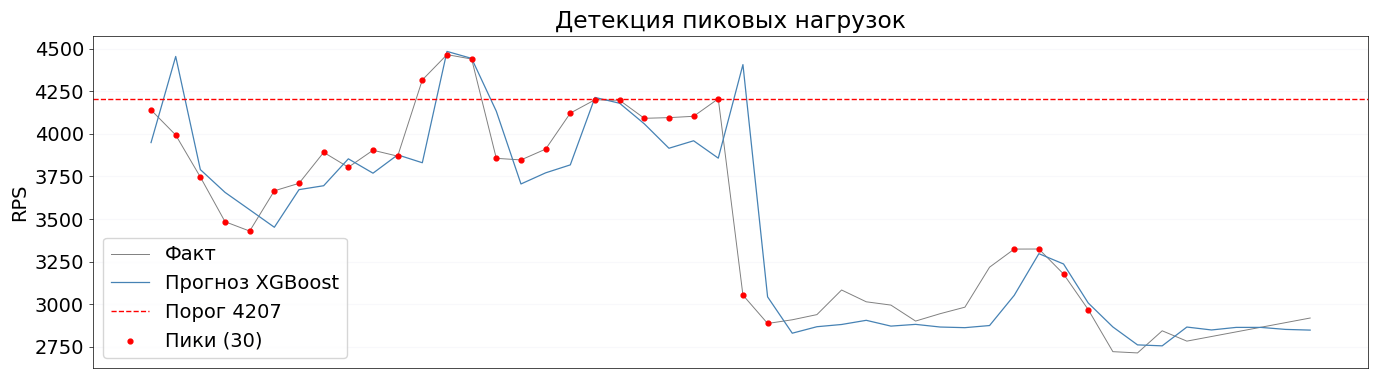


Первые 10 пиков:


,timestamp,rps,predicted,severity,recommended_replicas
0,1970-01-01 00:00:00.000001800,4140.632396,3948.856201,critical,5
1,1970-01-01 00:00:00.000001801,3993.333084,4454.771973,exceeded,5
2,1970-01-01 00:00:00.000001802,3746.379847,3790.127441,critical,5
3,1970-01-01 00:00:00.000001803,3484.180157,3656.436279,critical,4
4,1970-01-01 00:00:00.000001804,3429.130831,3554.242188,warning,4
5,1970-01-01 00:00:00.000001805,3665.669311,3451.482422,warning,4
6,1970-01-01 00:00:00.000001806,3709.556391,3672.568848,critical,4
7,1970-01-01 00:00:00.000001807,3891.522427,3695.475830,critical,4
8,1970-01-01 00:00:00.000001808,3804.076736,3853.517822,critical,5
9,1970-01-01 00:00:00.000001809,3903.887464,3769.091309,critical,4


In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(events_df['timestamp'], events_df['rps'],       color='gray',      linewidth=0.7, label='Факт')
ax.plot(events_df['timestamp'], events_df['predicted'], color='steelblue', linewidth=0.9, label='Прогноз XGBoost')
ax.axhline(summary_pk['threshold'], color='red', linestyle='--', linewidth=1.0,
           label=f'Порог {summary_pk["threshold"]:.0f}')
peaks = events_df[events_df['is_peak']]
ax.scatter(peaks['timestamp'], peaks['rps'], color='red', s=12, zorder=5, label=f'Пики ({len(peaks)})')
ax.set_title('Детекция пиковых нагрузок')
ax.set_ylabel('RPS'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/peak_detection.png', dpi=150)
plt.show()

if peaks.shape[0] > 0:
    print('\nПервые 10 пиков:')
    display(peaks[['timestamp','rps','predicted','severity','recommended_replicas']].head(10))

## §4.3 — Walk-Forward валидация с адаптивным переобучением

Модель прогнозирует **точка за точкой**. При обнаружении концепт-дрейфа
(ADWIN или принудительно через `WF_N_FRESH` шагов) переобучается на всей
накопленной истории. Рядом идёт **фиксированная baseline-модель** для сравнения.

In [16]:
import os, sys
REPO_DIR = '/content/Dyplom'
if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)

import joblib
from evaluation.walk_forward import run_walk_forward
from retraining.scheduler import make_xgb_train_fn
from retraining.drift_detector import ADWINDriftDetector
from models.forecasters import predict_xgboost_wf
from preprocessing.feature_engineering import FeatureBuilder

initial_xgb = comparator.models_.get('XGBoost') or joblib.load(f'{SAVE_DIR}/xgboost.pkl')
builder_wf  = FeatureBuilder()
drift_det   = ADWINDriftDetector(n_fresh=WF_N_FRESH, confirmation_n=WF_CONFIRM_N)
train_fn_wf = make_xgb_train_fn(builder_wf, save_dir=SAVE_DIR)
test_wf     = test.iloc[:WF_TEST_LIMIT].reset_index(drop=True) if WF_TEST_LIMIT else test.reset_index(drop=True)

print(f'Walk-forward: {len(test_wf)} шагов, n_fresh={WF_N_FRESH}, confirm={WF_CONFIRM_N}\n')

wf_res = run_walk_forward(
    train=train, val=val, test=test_wf,
    initial_model=initial_xgb,
    predict_fn=predict_xgboost_wf,
    train_fn=train_fn_wf,
    builder=builder_wf,
    drift_detector=drift_det,
    save_dir=SAVE_DIR,
    verbose=True,
)

Walk-forward: 360 шагов, n_fresh=200, confirm=10

Baseline MAE: 959.065

  шаг 0/360, MAE адапт.=291.72, MAE baseline=291.72
  шаг 50/360, MAE адапт.=24.44, MAE baseline=24.44
  шаг 100/360, MAE адапт.=2240.30, MAE baseline=2240.30
  шаг 150/360, MAE адапт.=632.26, MAE baseline=632.26
  XGBoost Random Search: 30 итераций...
    [1/30] новый лучший RMSE=157.5232  params={'max_depth': 4, 'learning_rate': 0.07, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'reg_alpha': 0.3, 'reg_lambda': 0.5}
    [3/30] новый лучший RMSE=154.0670  params={'max_depth': 7, 'learning_rate': 0.07, 'subsample': 0.8, 'colsample_bytree': 0.6, 'min_child_weight': 7, 'reg_alpha': 0.05, 'reg_lambda': 1.5}
    [5/30] новый лучший RMSE=153.3746  params={'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'reg_alpha': 0.1, 'reg_lambda': 2.0}
    [6/30] новый лучший RMSE=147.6393  params={'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.9, 'co

In [17]:
import numpy as np

res_df     = wf_res['results_df']
base_df    = wf_res['baseline_df']
summary_wf = wf_res['summary']
retrains   = summary_wf['retrain_timestamps']

print('=' * 50)
print('ИТОГ WALK-FORWARD')
print('=' * 50)
print(f'MAE адаптивная   : {summary_wf["mae_adaptive"]}')
print(f'MAE фиксированная: {summary_wf["mae_baseline"]}')
print(f'Улучшение        : {summary_wf["improvement_pct"]}%')
print(f'Переобучений     : {summary_wf["n_retrains"]}')
if summary_wf['retrain_intervals']:
    iv = summary_wf['retrain_intervals']
    print(f'Интервалы (шаги) : min={min(iv)}, max={max(iv)}, mean={np.mean(iv):.0f}')

ИТОГ WALK-FORWARD
MAE адаптивная   : 608.258
MAE фиксированная: 611.943
Улучшение        : 0.6%
Переобучений     : 1
Интервалы (шаги) : min=199, max=199, mean=199


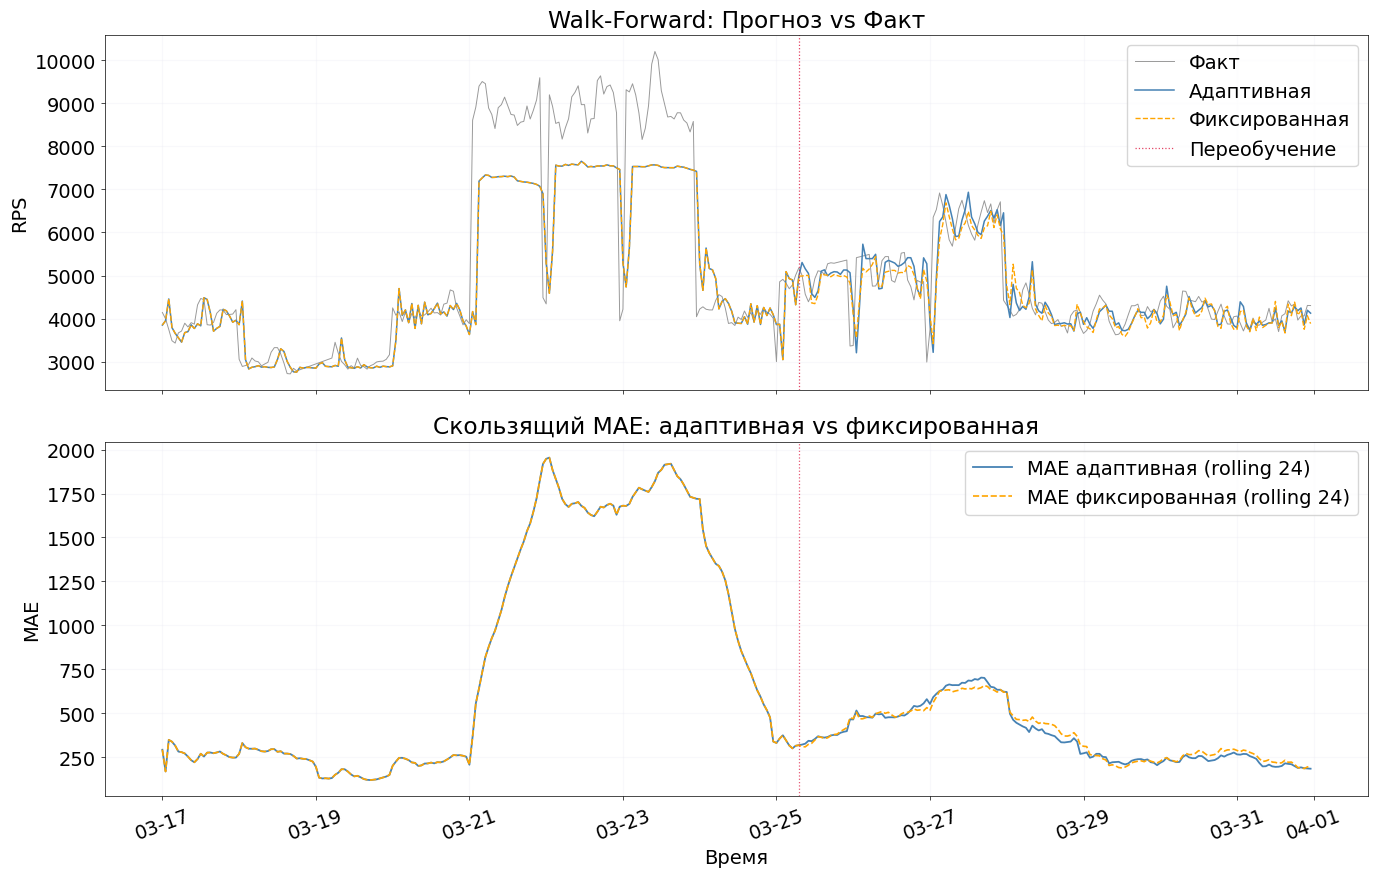

Сохранено: /content/results/walk_forward_combined.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1 = axes[0]
ax1.plot(res_df['timestamp'],  res_df['y_true'],  color='gray',      linewidth=0.7, alpha=0.8, label='Факт')
ax1.plot(res_df['timestamp'],  res_df['y_pred'],  color='steelblue', linewidth=1.1, label='Адаптивная')
if 'y_pred_baseline' in base_df.columns:
    ax1.plot(base_df['timestamp'], base_df['y_pred_baseline'], color='orange', linewidth=1.0,
             linestyle='--', label='Фиксированная')
for i, ts in enumerate(retrains):
    ax1.axvline(ts, color='crimson', linestyle=':', linewidth=0.9, alpha=0.8,
                label='Переобучение' if i == 0 else None)
ax1.set_title('Walk-Forward: Прогноз vs Факт')
ax1.set_ylabel('RPS'); ax1.legend(loc='upper right'); ax1.grid(alpha=0.3)

ax2 = axes[1]
w = min(24, max(1, len(res_df) // 10))
roll_a = res_df['mae'].rolling(w, min_periods=1).mean()
roll_b = base_df['mae_baseline'].rolling(w, min_periods=1).mean()
ax2.plot(res_df['timestamp'],  roll_a, color='steelblue', linewidth=1.3, label=f'MAE адаптивная (rolling {w})')
ax2.plot(base_df['timestamp'], roll_b, color='orange',    linewidth=1.2, linestyle='--',
         label=f'MAE фиксированная (rolling {w})')
for ts in retrains:
    ax2.axvline(ts, color='crimson', linestyle=':', linewidth=0.9, alpha=0.7)
ax2.set_title('Скользящий MAE: адаптивная vs фиксированная')
ax2.set_ylabel('MAE'); ax2.set_xlabel('Время')
ax2.legend(loc='upper right'); ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/walk_forward_combined.png', dpi=150)
plt.show()
print(f'Сохранено: {SAVE_DIR}/walk_forward_combined.png')

Событий переобучения: 1


,timestamp,reason,n_observations,baseline_mae_before,rolling_mae_before,new_baseline_mae,train_size,duration_s
0,2026-05-27T18:09:24Z,n_fresh,200,959.065054,808.972717,103.33583,2000,7.17


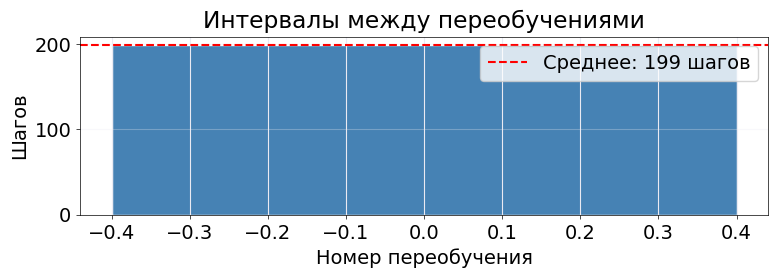

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Лог переобучений
log_path = f'{SAVE_DIR}/walk_forward_log.csv'
if os.path.exists(log_path):
    log_df = pd.read_csv(log_path)
    print(f'Событий переобучения: {len(log_df)}')
    display(log_df)

# Интервалы между переобучениями
if summary_wf['retrain_intervals']:
    iv = summary_wf['retrain_intervals']
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(range(len(iv)), iv, color='steelblue', edgecolor='white')
    ax.axhline(np.mean(iv), color='red', linestyle='--', label=f'Среднее: {np.mean(iv):.0f} шагов')
    ax.set_title('Интервалы между переобучениями')
    ax.set_xlabel('Номер переобучения'); ax.set_ylabel('Шагов')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/retrain_intervals.png', dpi=150)
    plt.show()

## §4.4 — Итоговая сводка и экспорт

In [ ]:
import os, pandas as pd, numpy as np

print('=' * 60)
print('ИТОГОВАЯ СВОДКА ЭКСПЕРИМЕНТА')
print('=' * 60)

print('\n§4.1  Сравнение моделей:')
display(metrics_df[['MAE','RMSE','MAPE']].round(2))

print(f'\n§4.2  Детекция пиков:')
print(f'  Порог: {summary_pk["threshold"]:.0f} RPS')
print(f'  Пиков: {summary_pk["peaks_detected"]} / {summary_pk["total_points"]} ({summary_pk["peak_ratio_pct"]}%)')

print(f'\n§4.3  Walk-Forward:')
print(f'  MAE адаптивная   : {summary_wf["mae_adaptive"]}')
print(f'  MAE фиксированная: {summary_wf["mae_baseline"]}')
print(f'  Улучшение        : {summary_wf["improvement_pct"]}%')
print(f'  Переобучений     : {summary_wf["n_retrains"]}')

summary_row = {
    'best_model':         best_name,
    **{f'{n}_mae': v.get('MAE') for n, v in comparator.results_.items()},
    'peak_threshold':     summary_pk['threshold'],
    'peaks_detected':     summary_pk['peaks_detected'],
    'wf_mae_adaptive':    summary_wf['mae_adaptive'],
    'wf_mae_baseline':    summary_wf['mae_baseline'],
    'wf_improvement_pct': summary_wf['improvement_pct'],
    'wf_n_retrains':      summary_wf['n_retrains'],
}
pd.DataFrame([summary_row]).to_csv(f'{SAVE_DIR}/experiment_summary.csv', index=False)

print(f'\nВсе файлы в {SAVE_DIR}/')
for f in sorted(os.listdir(SAVE_DIR)):
    kb = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024
    print(f'  {f:<45} {kb:.1f} KB')